# 3D Autoencoder Predictive Modeling Experiments
## Johns Hopkins Capstone — Learning Food Affordability Representations
### Gilberto Rios & Arul Pandita | Spring 2026

---

### Notebook Overview

Two experiments comparing predictive performance **with and without spatial lag features**:

| | Experiment |
|---|---|
| **Exp 1** | 3D Autoencoder + Controls (no spatial lags) |
| **Exp 2** | 3D Autoencoder + Controls + Spatial Lags |

- **Models:** Random Forest · XGBoost
- **Outcomes:** Obesity Rate · Diabetes Rate · Medicare Cost Per Capita
- **Cross-Validation:** State-Based CV (hold out all counties from N states per fold)

> **Why State-Based CV instead of random K-Fold?**
> Standard K-Fold shuffles randomly, so neighboring counties end up in both train and
> test sets. Because your spatial lag features (WX_AE_*) encode neighborhood information,
> the model can effectively peek at the test set through its neighbors — inflating R².
> Holding out entire states forces the model to generalize to unseen regions, giving a
> more honest estimate of out-of-sample performance.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Configuration
**Update the column names here if they differ in your dataset.**

In [13]:
DATA_PATH = 'final_spatial_ml_dataset.csv'

# ── Outcome variables ──────────────────────────────────────────────
OUTCOMES = {
    'obesity_rate':            'Obesity Rate (%)',
    'diabetes_rate':           'Diabetes Rate (%)',
    'TOT_MDCR_STDZD_PYMT_PC': 'Medicare Cost Per Capita ($)'
}

# ── Feature sets ───────────────────────────────────────────────────
AE_3D_FEATURES = ['AE3d_latent1', 'AE3d_latent2', 'AE3d_latent3']

SPATIAL_LAGS   = ['WX_AE_1', 'WX_AE_2', 'WX_AE_3']

CONTROLS = [
    'min_wage_2023',
    'poverty_rate',
    'population_density',
    'Median_Household_Income',
    'mean_commute_time'
]

# ── State-based CV ─────────────────────────────────────────────────
STATE_COL = 'State'   # ← update if your column is named differently
N_FOLDS   = 5              # number of state groups to hold out

print('✅ Configuration loaded')

✅ Configuration loaded


## 3. Load & Validate Data

In [16]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 2,226 rows × 68 columns


,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,FIPS,NAME_x,LSAD,ALAND,AWATER,State,...,AE3d_latent1,AE3d_latent2,AE3d_latent3,AE4d_latent1,AE4d_latent2,AE4d_latent3,AE4d_latent4,WX_AE_1,WX_AE_2,WX_AE_3
0,21,65,516879,0500000US21065,21065,Estill,6,655509930,6516335,KY,...,0.433675,0.920785,0.688363,0.412112,0.743767,1.983642,-0.931843,0.231862,0.893501,-0.205838
1,21,69,516881,0500000US21069,21069,Fleming,6,902727151,7182793,KY,...,0.207441,0.778524,0.717455,0.124996,1.124417,2.023833,-1.358574,0.179396,0.556709,0.546720
2,21,93,516893,0500000US21093,21093,Hardin,6,1614569777,17463238,KY,...,0.158670,0.980106,-0.567834,0.971051,3.233359,3.182320,-2.164850,0.042171,1.112653,-0.039535
3,21,99,516896,0500000US21099,21099,Hart,6,1068530028,13692536,KY,...,0.489203,0.395630,0.461091,0.471604,1.522535,2.281766,-1.951748,0.396219,0.617428,-0.080139
4,21,131,516912,0500000US21131,21131,Leslie,6,1038206077,9189732,KY,...,0.497089,0.813632,0.994650,0.215946,0.360995,1.762524,-0.909943,0.919321,0.706550,-0.099234


In [18]:
# Column validation
all_required = AE_3D_FEATURES + SPATIAL_LAGS + CONTROLS + list(OUTCOMES.keys())

missing_model   = [c for c in all_required if c not in df.columns]
missing_state   = STATE_COL not in df.columns

if missing_model:
    print(f'⚠️  Missing feature/outcome columns: {missing_model}')
    ae_cols = [c for c in df.columns if any(k in c for k in ['AE', 'WX', 'latent'])]
    print(f'   AE/WX/latent columns available: {ae_cols}')
else:
    print('✅ All model feature columns found')

if missing_state:
    print(f"⚠️  State column '{STATE_COL}' not found — update STATE_COL in config")
    print(f'   Candidate columns: {[c for c in df.columns if "state" in c.lower() or "fips" in c.lower()]}')
else:
    n_states = df[STATE_COL].nunique()
    print(f'✅ State column found: {n_states} unique states/territories')

✅ All model feature columns found
✅ State column found: 50 unique states/territories


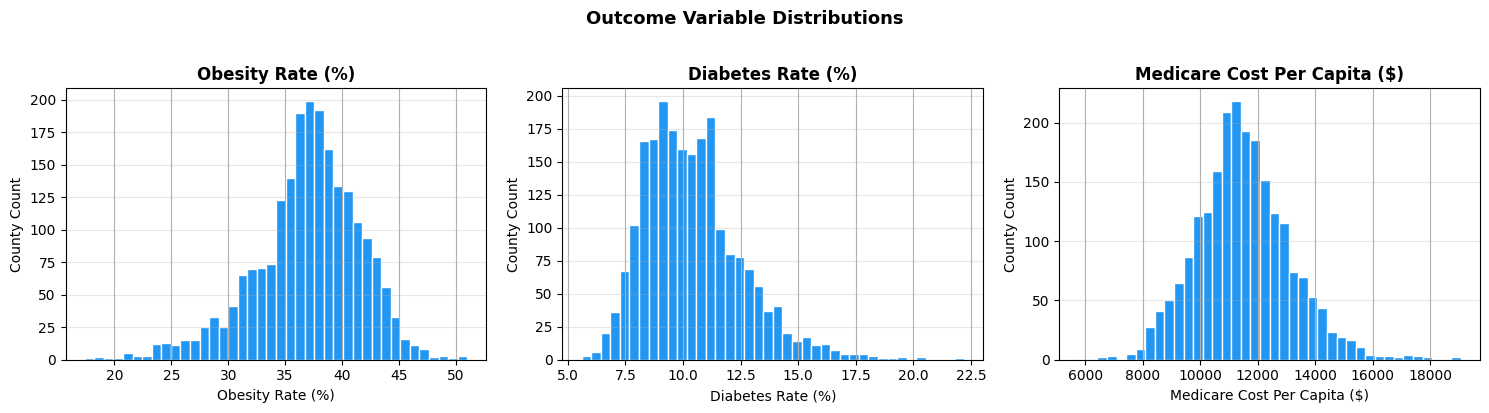

In [20]:
# Outcome distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, label) in zip(axes, OUTCOMES.items()):
    if col in df.columns:
        df[col].dropna().hist(bins=40, ax=ax, color='#2196F3', edgecolor='white')
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel(label)
        ax.set_ylabel('County Count')
        ax.grid(axis='y', alpha=0.3)
plt.suptitle('Outcome Variable Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Experiment Definitions

In [23]:
EXPERIMENTS = {
    'AE3D_NoSpatial': {
        'name':     '3D AE + Controls (NO Spatial)',
        'features': AE_3D_FEATURES + CONTROLS
    },
    'AE3D_WithSpatial': {
        'name':     '3D AE + Controls + Spatial Lags',
        'features': AE_3D_FEATURES + CONTROLS + SPATIAL_LAGS
    }
}

for key, cfg in EXPERIMENTS.items():
    print(f"{cfg['name']}")
    print(f"  Features ({len(cfg['features'])}): {cfg['features']}\n")

3D AE + Controls (NO Spatial)
  Features (8): ['AE3d_latent1', 'AE3d_latent2', 'AE3d_latent3', 'min_wage_2023', 'poverty_rate', 'population_density', 'Median_Household_Income', 'mean_commute_time']

3D AE + Controls + Spatial Lags
  Features (11): ['AE3d_latent1', 'AE3d_latent2', 'AE3d_latent3', 'min_wage_2023', 'poverty_rate', 'population_density', 'Median_Household_Income', 'mean_commute_time', 'WX_AE_1', 'WX_AE_2', 'WX_AE_3']



## 5. State-Based Cross-Validation

**How it works:**
1. Collect all unique states in the dataset
2. Shuffle and divide them into `N_FOLDS` groups
3. For each fold: hold out all counties in that state group as the test set

This guarantees the model never sees any county from a held-out state during training,
testing true geographic generalization rather than interpolation within a region.

In [26]:
def make_state_folds(df_model, state_col, n_folds, random_state=42):
    """
    Build state-based CV folds.

    Parameters
    ----------
    df_model     : DataFrame with state_col present, reset index
    state_col    : column containing state identifiers (FIPS or abbreviation)
    n_folds      : number of fold groups
    random_state : for reproducibility

    Returns
    -------
    folds : list of (train_idx, test_idx) integer index arrays
    fold_states : list of state lists held out per fold
    """
    states = df_model[state_col].unique()
    rng = np.random.default_rng(random_state)
    rng.shuffle(states)

    state_groups = np.array_split(states, n_folds)
    folds, fold_states = [], []

    for held_out in state_groups:
        test_mask = df_model[state_col].isin(held_out)
        train_idx = np.where(~test_mask)[0]
        test_idx  = np.where( test_mask)[0]
        if len(test_idx) > 0 and len(train_idx) > 0:
            folds.append((train_idx, test_idx))
            fold_states.append(list(held_out))

    return folds, fold_states


# Preview fold composition on the full dataset
if STATE_COL in df.columns:
    demo_folds, demo_states = make_state_folds(df, STATE_COL, N_FOLDS)
    print(f'State-Based CV — {len(demo_folds)} folds from {df[STATE_COL].nunique()} states\n')
    for i, (states_held, (tr, te)) in enumerate(zip(demo_states, demo_folds), 1):
        print(f'  Fold {i}: hold out {len(states_held)} state(s) → '
              f'{len(te):,} test counties, {len(tr):,} train counties')
        print(f'          States: {states_held}')
else:
    print(f"⚠️  '{STATE_COL}' not found — update STATE_COL in config before running")

State-Based CV — 5 folds from 50 states

  Fold 1: hold out 10 state(s) → 294 test counties, 1,932 train counties
          States: ['AR', 'ND', 'IA', 'RI', 'NE', 'UT', 'DE', 'WY', 'VT', 'LA']
  Fold 2: hold out 10 state(s) → 426 test counties, 1,800 train counties
          States: ['MN', 'SC', 'NV', 'NY', 'ME', 'CO', 'AK', 'MS', 'OR', 'NC']
  Fold 3: hold out 10 state(s) → 336 test counties, 1,890 train counties
          States: ['MA', 'FL', 'OK', 'NJ', 'OH', 'NH', 'WA', 'AZ', 'SD', 'MT']
  Fold 4: hold out 10 state(s) → 496 test counties, 1,730 train counties
          States: ['AL', 'WI', 'PA', 'GA', 'WV', 'CA', 'HI', 'NM', 'MD', 'MI']
  Fold 5: hold out 10 state(s) → 674 test counties, 1,552 train counties
          States: ['KY', 'ID', 'MO', 'KS', 'IN', 'VA', 'TN', 'IL', 'TX', 'DC']


## 6. Model Definitions

In [29]:
def get_model(model_name):
    """Return a fresh, configured model instance."""
    if model_name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    elif model_name == 'XGBoost':
        return XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
    else:
        raise ValueError(f'Unknown model: {model_name}')


def run_state_cv(X, y, folds):
    """
    Run both models across the given state-based folds.

    Returns
    -------
    results : dict keyed by model_name → aggregated metrics dict
    """
    models = ['RandomForest', 'XGBoost']
    results = {}

    for model_name in models:
        fold_results = []

        for fold_idx, (train_idx, test_idx) in enumerate(folds, 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train)
            X_test_sc  = scaler.transform(X_test)

            model = get_model(model_name)
            model.fit(X_train_sc, y_train)
            y_pred = model.predict(X_test_sc)

            fold_results.append({
                'fold':  fold_idx,
                'r2':    r2_score(y_test, y_pred),
                'rmse':  np.sqrt(mean_squared_error(y_test, y_pred)),
                'mae':   mean_absolute_error(y_test, y_pred),
                'n_test': len(test_idx)
            })

        results[model_name] = {
            'r2_mean':      np.mean([r['r2']   for r in fold_results]),
            'r2_std':       np.std( [r['r2']   for r in fold_results]),
            'rmse_mean':    np.mean([r['rmse'] for r in fold_results]),
            'rmse_std':     np.std( [r['rmse'] for r in fold_results]),
            'mae_mean':     np.mean([r['mae']  for r in fold_results]),
            'fold_details': fold_results
        }

    return results


print('✅ Model and CV functions defined')

✅ Model and CV functions defined


## 7. Run All Experiments

Loop: **3 outcomes × 2 experiments × 2 models = 12 runs**, each using state-based CV.

In [32]:
all_results = []

for outcome_var, outcome_name in OUTCOMES.items():
    print(f"\n{'='*65}")
    print(f'OUTCOME: {outcome_name}')
    print(f"{'='*65}")

    if outcome_var not in df.columns:
        print('  ⚠️  Column not found — skipping')
        continue

    for exp_key, exp_config in EXPERIMENTS.items():
        feature_cols  = exp_config['features']
        required_cols = feature_cols + [outcome_var, STATE_COL]

        df_model = df[required_cols].dropna(subset=feature_cols + [outcome_var])
        df_model = df_model.reset_index(drop=True)

        if len(df_model) < 100:
            print(f"  ⚠️  Only {len(df_model)} rows — skipping {exp_config['name']}")
            continue

        X = df_model[feature_cols]
        y = df_model[outcome_var]

        # Build state-based folds on this model's sample
        folds, fold_states = make_state_folds(df_model, STATE_COL, N_FOLDS)

        print(f"\n  {exp_config['name']}  (n={len(df_model):,}, {len(folds)} folds)")

        cv_results = run_state_cv(X, y, folds)

        for model_name, res in cv_results.items():
            print(f"    {model_name:12s}  R² = {res['r2_mean']:.4f} ± {res['r2_std']:.4f}  "
                  f"RMSE = {res['rmse_mean']:.4f} ± {res['rmse_std']:.4f}")

            all_results.append({
                'Outcome':    outcome_name,
                'Experiment': exp_config['name'],
                'Model':      model_name,
                'R2_Mean':    res['r2_mean'],
                'R2_Std':     res['r2_std'],
                'RMSE_Mean':  res['rmse_mean'],
                'RMSE_Std':   res['rmse_std'],
                'MAE_Mean':   res['mae_mean'],
                'N_Samples':  len(df_model),
                'N_Features': len(feature_cols)
            })

print("\n" + "="*65)
print('✅ ALL EXPERIMENTS COMPLETE')
print("="*65)


OUTCOME: Obesity Rate (%)

  3D AE + Controls (NO Spatial)  (n=2,168, 5 folds)
    RandomForest  R² = 0.5462 ± 0.0866  RMSE = 3.0933 ± 0.5392
    XGBoost       R² = 0.5258 ± 0.1161  RMSE = 3.1389 ± 0.4952

  3D AE + Controls + Spatial Lags  (n=2,168, 5 folds)
    RandomForest  R² = 0.5392 ± 0.0928  RMSE = 3.1101 ± 0.5214
    XGBoost       R² = 0.5202 ± 0.1098  RMSE = 3.1630 ± 0.5252

OUTCOME: Diabetes Rate (%)

  3D AE + Controls (NO Spatial)  (n=2,168, 5 folds)
    RandomForest  R² = 0.6651 ± 0.1142  RMSE = 1.1879 ± 0.1215
    XGBoost       R² = 0.6540 ± 0.1039  RMSE = 1.2134 ± 0.1019

  3D AE + Controls + Spatial Lags  (n=2,168, 5 folds)
    RandomForest  R² = 0.6726 ± 0.1150  RMSE = 1.1747 ± 0.1349
    XGBoost       R² = 0.6688 ± 0.1034  RMSE = 1.1883 ± 0.1270

OUTCOME: Medicare Cost Per Capita ($)

  3D AE + Controls (NO Spatial)  (n=2,226, 5 folds)
    RandomForest  R² = 0.1748 ± 0.1192  RMSE = 1466.3791 ± 123.8350
    XGBoost       R² = 0.1283 ± 0.1254  RMSE = 1505.6098 ± 102.11

## 8. Results Table & Spatial Lag Impact

In [34]:
results_df = pd.DataFrame(all_results)
results_df.to_csv('ae3d_state_cv_results.csv', index=False)
print('✅ Saved: ae3d_state_cv_results.csv\n')

# Pivot table: quick overview
pivot = results_df.pivot_table(
    index=['Outcome', 'Model'],
    columns='Experiment',
    values=['R2_Mean', 'RMSE_Mean']
).round(4)
pivot

✅ Saved: ae3d_state_cv_results.csv



R2_Mean  \
Experiment                                3D AE + Controls (NO Spatial)   
Outcome                      Model                                        
Diabetes Rate (%)            RandomForest                        0.6651   
                             XGBoost                             0.6540   
Medicare Cost Per Capita ($) RandomForest                        0.1748   
                             XGBoost                             0.1283   
Obesity Rate (%)             RandomForest                        0.5462   
                             XGBoost                             0.5258   

                                                                           \
Experiment                                3D AE + Controls + Spatial Lags   
Outcome                      Model                                          
Diabetes Rate (%)            RandomForest                          0.6726   
                             XGBoost                               0.6688   
Medicare Cost Per Capita ($) RandomForest                          0.2497   
                             XGBoost                               0.1880   
Obesity Rate (%)             RandomForest                          0.5392   
                             XGBoost                               0.5202   

                                                              RMSE_Mean  \
Experiment                                3D AE + Controls (NO Spatial)   
Outcome                      Model                                        
Diabetes Rate (%)            RandomForest                        1.1879   
                             XGBoost                             1.2134   
Medicare Cost Per Capita ($) RandomForest                     1466.3791   
                             XGBoost                          1505.6098   
Obesity Rate (%)             RandomForest                        3.0933   
                             XGBoost                             3.1389   

                                                                           
Experiment                                3D AE + Controls + Spatial Lags  
Outcome                      Model                                         
Diabetes Rate (%)            RandomForest                          1.1747  
                             XGBoost                               1.1883  
Medicare Cost Per Capita ($) RandomForest                       1396.5112  
                             XGBoost                            1450.6233  
Obesity Rate (%)             RandomForest                          3.1101  
                             XGBoost                               3.1630

In [35]:
# Spatial lag impact: % R² improvement from adding spatial lags
print('SPATIAL LAG IMPACT (State-Based CV)\n' + '='*65)

for outcome in OUTCOMES.values():
    print(f'\n{outcome}:')
    oc = results_df[results_df['Outcome'] == outcome]

    for model in ['RandomForest', 'XGBoost']:
        m = oc[oc['Model'] == model]
        if len(m) < 2:
            continue

        no_sp   = m[m['Experiment'].str.contains('NO')]['R2_Mean'].values[0]
        with_sp = m[~m['Experiment'].str.contains('NO')]['R2_Mean'].values[0]
        pct     = (with_sp - no_sp) / abs(no_sp) * 100
        symbol  = '↑' if pct > 0 else '↓'

        print(f'  {model:12s}: {no_sp:.4f} → {with_sp:.4f}  ({symbol}{abs(pct):.2f}%)')

SPATIAL LAG IMPACT (State-Based CV)

Obesity Rate (%):
  RandomForest: 0.5462 → 0.5392  (↓1.29%)
  XGBoost     : 0.5258 → 0.5202  (↓1.07%)

Diabetes Rate (%):
  RandomForest: 0.6651 → 0.6726  (↑1.13%)
  XGBoost     : 0.6540 → 0.6688  (↑2.26%)

Medicare Cost Per Capita ($):
  RandomForest: 0.1748 → 0.2497  (↑42.86%)
  XGBoost     : 0.1283 → 0.1880  (↑46.45%)


## 9. Visualizations

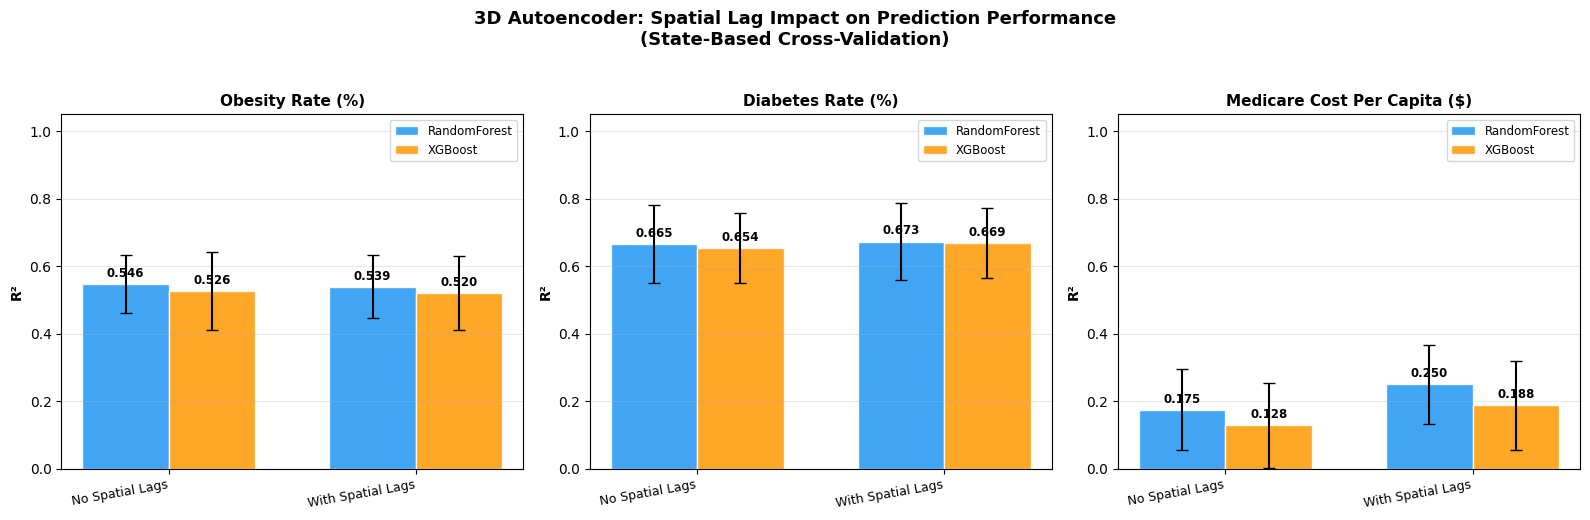

✅ Saved: ae3d_state_cv_comparison.png


In [40]:
# ── R² comparison: No Spatial vs With Spatial, grouped by model ──

palette = {'RandomForest': '#2196F3', 'XGBoost': '#FF9800'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for col_idx, (outcome_var, outcome_name) in enumerate(OUTCOMES.items()):
    ax = axes[col_idx]
    oc_data = results_df[results_df['Outcome'] == outcome_name]

    x_labels = ['No Spatial Lags', 'With Spatial Lags']
    x = np.arange(len(x_labels))
    width = 0.35

    for m_idx, model in enumerate(['RandomForest', 'XGBoost']):
        m_data = oc_data[oc_data['Model'] == model]

        r2_no   = m_data[m_data['Experiment'].str.contains('NO')]['R2_Mean'].values
        r2_with = m_data[~m_data['Experiment'].str.contains('NO')]['R2_Mean'].values
        r2_vals = [r2_no[0] if len(r2_no) else 0, r2_with[0] if len(r2_with) else 0]

        err_no   = m_data[m_data['Experiment'].str.contains('NO')]['R2_Std'].values
        err_with = m_data[~m_data['Experiment'].str.contains('NO')]['R2_Std'].values
        r2_errs  = [err_no[0] if len(err_no) else 0, err_with[0] if len(err_with) else 0]

        bars = ax.bar(
            x + m_idx * width, r2_vals, width,
            label=model, yerr=r2_errs, capsize=4,
            color=palette[model], alpha=0.85, edgecolor='white', linewidth=1
        )
        for bar, val in zip(bars, r2_vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold'
            )

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(x_labels, rotation=10, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('R²', fontweight='bold')
    ax.set_title(outcome_name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    '3D Autoencoder: Spatial Lag Impact on Prediction Performance\n'
    '(State-Based Cross-Validation)',
    fontsize=13, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('ae3d_state_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: ae3d_state_cv_comparison.png')

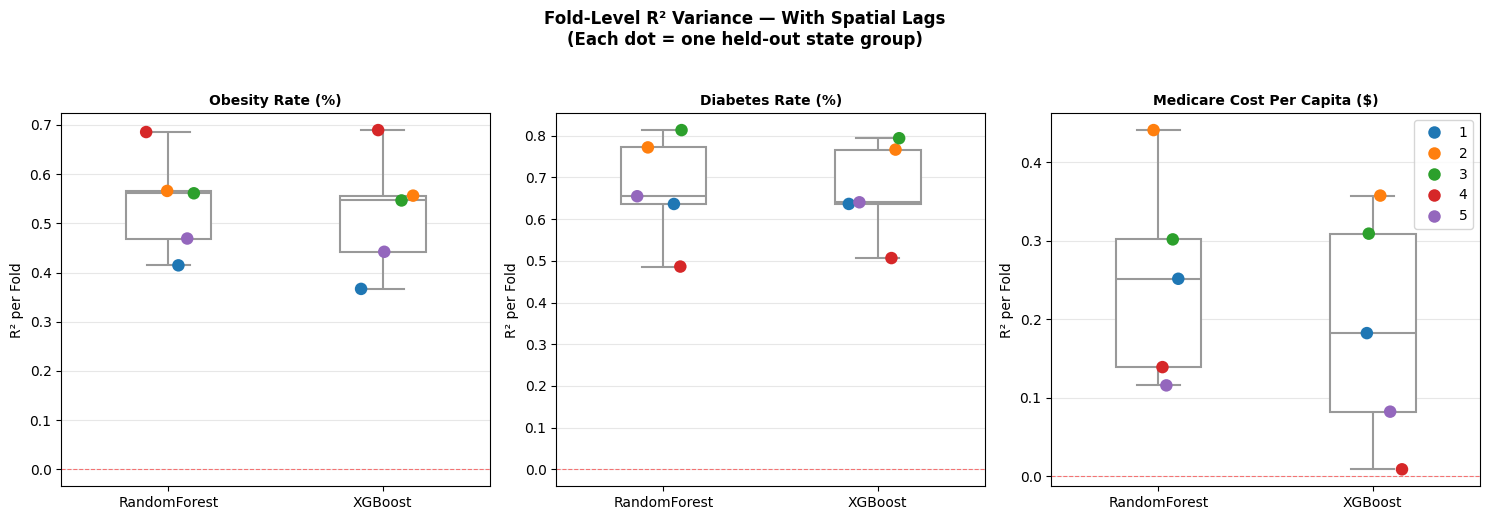

✅ Saved: ae3d_fold_variance.png


In [42]:
# ── Per-fold R² strip plot — shows variance across held-out state groups ──

# Re-run to collect fold-level detail for the With Spatial experiment
fold_records = []

for outcome_var, outcome_name in OUTCOMES.items():
    if outcome_var not in df.columns:
        continue

    feature_cols  = EXPERIMENTS['AE3D_WithSpatial']['features']
    required_cols = feature_cols + [outcome_var, STATE_COL]

    df_model = df[required_cols].dropna(subset=feature_cols + [outcome_var]).reset_index(drop=True)
    folds, fold_states = make_state_folds(df_model, STATE_COL, N_FOLDS)

    X = df_model[feature_cols]
    y = df_model[outcome_var]

    for model_name in ['RandomForest', 'XGBoost']:
        for fold_idx, (train_idx, test_idx) in enumerate(folds, 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            scaler = StandardScaler()
            model  = get_model(model_name)
            model.fit(scaler.fit_transform(X_train), y_train)
            y_pred = model.predict(scaler.transform(X_test))

            fold_records.append({
                'Outcome': outcome_name,
                'Model':   model_name,
                'Fold':    fold_idx,
                'R2':      r2_score(y_test, y_pred)
            })

fold_df = pd.DataFrame(fold_records)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for col_idx, (_, outcome_name) in enumerate(OUTCOMES.items()):
    ax = axes[col_idx]
    data = fold_df[fold_df['Outcome'] == outcome_name]

    sns.stripplot(
        data=data, x='Model', y='R2',
        hue='Fold', palette='tab10', size=9,
        jitter=0.15, ax=ax, legend=(col_idx == 2)
    )
    sns.boxplot(
        data=data, x='Model', y='R2',
        color='white', width=0.4, linewidth=1.5,
        fliersize=0, ax=ax
    )
    ax.set_title(outcome_name, fontweight='bold', fontsize=10)
    ax.set_ylabel('R² per Fold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.suptitle(
    'Fold-Level R² Variance — With Spatial Lags\n'
    '(Each dot = one held-out state group)',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('ae3d_fold_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: ae3d_fold_variance.png')

## 10. Next Steps

```
✅ DONE:  Predictive modeling — 3D AE embeddings + spatial lags
✅ DONE:  State-based spatial cross-validation
📅 TODO:  SHAP interpretability — which latent dimensions / controls drive predictions?
📅 TODO:  Double Machine Learning (DML) — causal effect of food affordability
📅 TODO:  What-if policy simulations
```

---
*Capstone: Learning Food Affordability Representations to Predict Obesity and Healthcare Costs in the United States*  
*Rios & Pandita — Johns Hopkins AMS Data Science, Spring 2026*